## NER Model Training

This notebook trains four NER models and saves them into `fitted_models/`.  
Each model is skipped automatically if its checkpoint already exists on disk, so it can be run safely.  
Run `reproduce_results.ipynb` to load and evaluate them.
| Model | Type | Saved to |
|-------|------|----------|
| CRF | Classical ML (handcrafted features) | `fitted_models/crf_model/crf_model.pkl` |
| Structured Perceptron | Classical ML (global linear) | `fitted_models/sp_model/sp_model.pkl` |
| BiLSTM-CRF | Deep learning | `fitted_models/bilstm_model/bilstm_crf.pt` |
| BERT | Pre-trained transformer | `fitted_models/bert_ner_model/` |

## 0. Dependencies

In [1]:
!pip install sklearn-crfsuite pytorch-crf transformers accelerate seqeval gensim -q

All shared utilities (data loading, CRF features, evaluation...) are implemented in `utils/utils.py`and are imported here.  
We set a fixed random seed (`SEED=42`) for NumPy, Python random and PyTorch to ensure reproducibility.

In [2]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), 'utils'))

import random, pickle
from collections import defaultdict, Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

import sklearn_crfsuite

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchcrf import CRF

import logging
logging.getLogger('transformers').setLevel(logging.ERROR)
from transformers import (
    AutoTokenizer, AutoModelForTokenClassification,
    TrainingArguments, Trainer, DataCollatorForTokenClassification,
)

from utils import (
    load_ner_csv, encode_crf, build_vocab, build_tag_map,
    load_glove_embeddings,
    sp_token_features, sp_viterbi, sp_update, train_structured_perceptron,
    evaluate_model,
)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DATA_DIR  = Path('data')
MODEL_DIR = Path('fitted_models')
MODEL_DIR.mkdir(exist_ok=True)
print('Setup OK')

Setup OK


## 1. Load data

The GMB corpus is provided as two CSV files with columns `sentence_id`, `words`, `tags`.  
Sentences are grouped by `sentence_id`; the split is disjoint (no shared sentence IDs).  

The 17 BIO labels cover eight entity types:

| Type | Meaning | Example |
|------|---------|---------|
| `geo` | Geographical location | *London*, *Iraq* |
| `gpe` | Geopolitical entity | *British*, *U.S.* |
| `org` | Organisation | *NATO*, *Microsoft* |
| `per` | Person | *Jack London* |
| `tim` | Time expression | *Saturday*, *2003* |
| `art` | Artefact | *AK-47* |
| `eve` | Event | *World Cup* |
| `nat` | Natural phenomenon | *hurricane* |

In [3]:
train_sents, train_labels = load_ner_csv(DATA_DIR / "train_data_ner.csv")
test_sents, test_labels   = load_ner_csv(DATA_DIR / "test_data_ner.csv")

print(f"Train sentences: {len(train_sents)}")
print(f"Test sentences: {len(test_sents)}")
print(f"Sample train sentence: {train_sents[0]}")
print(f"Sample train labels: {train_labels[0]}")
print(f"Sample test sentence: {test_sents[0]}")
print(f"Sample test labels: {test_labels[0]}")

all_labels = sorted({t for labels in train_labels + test_labels for t in labels})
non_O_labels = [t for t in all_labels if t != 'O']
print(f"All labels: {all_labels}")

Train sentences: 38366
Test sentences: 38367
Sample train sentence: ['Thousands', 'of', 'demonstrators', 'have', 'marched', 'through', 'London', 'to', 'protest', 'the', 'war', 'in', 'Iraq', 'and', 'demand', 'the', 'withdrawal', 'of', 'British', 'troops', 'from', 'that', 'country', '.']
Sample train labels: ['O', 'O', 'O', 'O', 'O', 'O', 'B-geo', 'O', 'O', 'O', 'O', 'O', 'B-geo', 'O', 'O', 'O', 'O', 'O', 'B-gpe', 'O', 'O', 'O', 'O', 'O']
Sample test sentence: ['Iranian', 'officials', 'say', 'they', 'expect', 'to', 'get', 'access', 'to', 'sealed', 'sensitive', 'parts', 'of', 'the', 'plant', 'Wednesday', ',', 'after', 'an', 'IAEA', 'surveillance', 'system', 'begins', 'functioning', '.']
Sample test labels: ['B-gpe', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-tim', 'O', 'O', 'O', 'B-org', 'O', 'O', 'O', 'O', 'O']
All labels: ['B-art', 'B-eve', 'B-geo', 'B-gpe', 'B-nat', 'B-org', 'B-per', 'B-tim', 'I-art', 'I-eve', 'I-geo', 'I-gpe', 'I-nat', 'I-org', 'I-per', '

## 2. EDA

Key observations to keep in mind when interpreting model results:

- **Class imbalance:** ~85% of all tokens are labelled `O` (Outside). All evaluation metrics in this project exclude `O` tokens to avoid inflated accuracy.
- **Rare classes:** `art`, `eve` and `nat` each represent less than 0.05% of tokens, making them the hardest to learn.
- **Vocabulary shift:** the test set contains ~12k unique tokens not seen during training (43,954 test vs 31,978 train unique tokens). This out-of-vocabulary gap is the primary driver of the train→test performance drop.

In [4]:
def eda(sents, labels, split_name):
    flat_labels = [t for seq in labels for t in seq]
    flat_words = [w for s in sents for w in s]
    sent_lens = [len(s) for s in sents]
    counts = Counter(flat_labels)

    print(f"{split_name} data:")
    print(f"Sentences: {len(sents)}")
    print(f"Tokens: {len(flat_words)}")
    print(f"Unique tok: {len(set(flat_words))}")
    print(
        f"Sent len: min={min(sent_lens)}, max={max(sent_lens)}, mean={np.mean(sent_lens):.1f}"
    )
    print(f"Label dist:")
    for lbl, cnt in sorted(counts.items(), key=lambda x: -x[1]):
        print(f"{lbl:15s}: {cnt:6d}  ({100*cnt/len(flat_labels):.1f}%)")


eda(train_sents, train_labels, "TRAIN")
print()
eda(test_sents, test_labels, "TEST")

TRAIN data:
Sentences: 38366
Tokens: 839141
Unique tok: 31978
Sent len: min=1, max=104, mean=21.9
Label dist:
O              : 710383  (84.7%)
B-geo          :  30113  (3.6%)
B-tim          :  16317  (1.9%)
B-org          :  16127  (1.9%)
I-per          :  13845  (1.6%)
B-per          :  13568  (1.6%)
I-org          :  13526  (1.6%)
B-gpe          :  12739  (1.5%)
I-geo          :   5898  (0.7%)
I-tim          :   5258  (0.6%)
B-art          :    314  (0.0%)
B-eve          :    244  (0.0%)
I-art          :    242  (0.0%)
I-eve          :    205  (0.0%)
I-gpe          :    161  (0.0%)
B-nat          :    157  (0.0%)
I-nat          :     44  (0.0%)

TEST data:
Sentences: 38367
Tokens: 837330
Unique tok: 43954
Sent len: min=1, max=104, mean=21.8
Label dist:
O              : 709097  (84.7%)
B-geo          :  30114  (3.6%)
B-tim          :  16131  (1.9%)
B-org          :  16019  (1.9%)
I-per          :  13830  (1.7%)
B-per          :  13691  (1.6%)
I-org          :  13281  (1.6%)
B-gpe     

The bar chart below shows the token counts per label in each split. Both splits have nearly identical distributions, confirming the sentence-ID-based split is stratified by content.

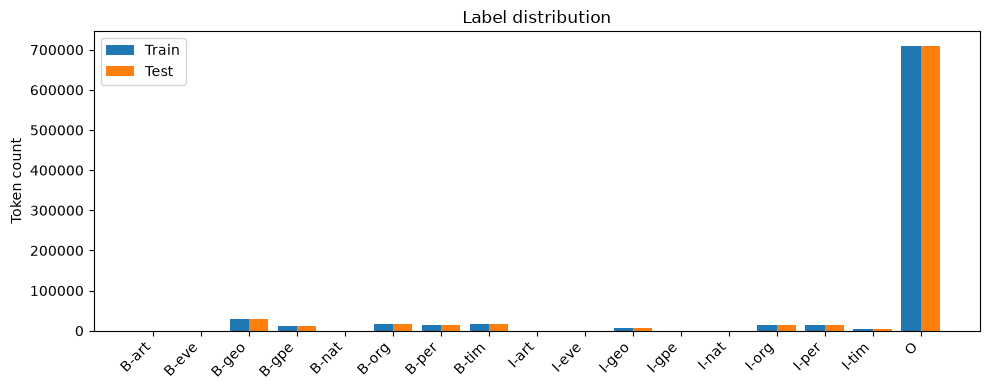

In [5]:
train_counts = Counter(t for seq in train_labels for t in seq)
test_counts = Counter(t for seq in test_labels  for t in seq)
labs = sorted(train_counts.keys())
x = np.arange(len(labs))
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - 0.2, [train_counts[l] for l in labs], 0.4, label='Train')
ax.bar(x + 0.2, [test_counts.get(l, 0) for l in labs], 0.4, label='Test')
ax.set_xticks(x)
ax.set_xticklabels(labs, rotation=45, ha='right')
ax.set_ylabel('Token count')
ax.set_title('Label distribution')
ax.legend()
plt.tight_layout()
plt.savefig(MODEL_DIR / 'label_distribution.png', dpi=120)
plt.show()

## 3. Model 1: CRF

A **linear-chain Conditional Random Field** assigns a probability to a complete tag sequence given an input sentence, learning feature weights jointly across all positions.

### Feature set (`word2features` in `utils.py`)

The feature function extracts the following signals at each token position `i`:

| Feature group | Examples |
|--------------|----------|
| Word identity | `word.lower = london` |
| Suffixes (2/3/4 chars) | `word[-3:] = don` |
| Prefixes (2/3/4 chars) | `word[:3] = lon` |
| Word shape | `John→Xxxx`, `NATO→XXXX`, `9th→dxx` |
| Boolean flags | `isupper`, `istitle`, `isdigit`, `hasdigit`, `hashyphen`, `hasdot`, camelCase |
| Caps ratio | fraction of uppercase characters |
| Context ±2 | lowercased form, title/upper flags, shape of neighbours |
| Bigrams | `prev_word + current_word`, `current_word + next_word` |
| Boundary | `BOS` (beginning of sentence), `EOS` (end of sentence) |

### Training choices

- **Algorithm:** L-BFGS (quasi-Newton, converges faster than SGD for CRFs)
- **Regularisation:** `c1=c2=0.1` — stronger than the default 0.01, necessary because the richer feature set generates ~11M features and risks overfitting without adequate L1/L2 penalty
- **`all_possible_states=True`:** adds per-label bias features, particularly helpful for rare classes (`B-nat`, `I-nat`, `B-art`) that would otherwise be starved of signal
- **`all_possible_transitions=True`:** ensures all tag-pair transition weights are learned even if some transitions never appear in training

In [6]:
X_train_crf, y_train_crf = encode_crf(train_sents, train_labels)
X_test_crf,  y_test_crf  = encode_crf(test_sents,  test_labels)
print('CRF features ready')

CRF features ready


In [7]:
CRF_PATH = MODEL_DIR / 'crf_model' / 'crf_model.pkl'

if CRF_PATH.exists():
    print(f'CRF already trained — loading from {CRF_PATH}')
    with open(CRF_PATH, 'rb') as f:
        crf = pickle.load(f)
else:
    crf = sklearn_crfsuite.CRF(
        algorithm='lbfgs',
        c1=0.1,                       # stronger regularisation for larger feature space
        c2=0.1,
        max_iterations=200,
        all_possible_transitions=True,
        all_possible_states=True,     # per-label bias terms
        verbose=True,
    )
    crf.fit(X_train_crf, y_train_crf)
    with open(CRF_PATH, 'wb') as f:
        pickle.dump(crf, f)
    print(f'CRF saved to {CRF_PATH}')

y_pred_crf_train = crf.predict(X_train_crf)
res = evaluate_model(y_train_crf, y_pred_crf_train, exclude_O=True)
print(f'CRF TRAIN  accuracy={res["accuracy"]:.4f}  F1-macro={res["f1_macro"]:.4f}')

CRF already trained — loading from fitted_models/crf_model/crf_model.pkl
CRF TRAIN  accuracy=0.9815  F1-macro=0.9723


## 4. Model 2: Structured Perceptron

The **Structured (Collins) Perceptron** is a global linear sequence labeller. At each training step:

1. Decode the best tag sequence with **Viterbi**
2. If prediction ≠ gold sequence, update weights: increment features of the gold sequence, decrement features of the predicted sequence
3. Repeat for all sentences, shuffle between epochs

### Averaged perceptron

We use the **averaged** variant, which instead of returning the final weight vector returns the average of *all* weight vectors seen across every update step. This acts as implicit regularisation and consistently improves generalisation compared to the plain perceptron.

### Feature set (`sp_token_features` in `utils.py`)

The same rich feature set as the CRF: word identity, 2/3/4-character affixes, word shape, boolean flags, bigram context, and a ±2 context window. Each feature is concatenated with the current label so the weight vector learns label-specific preferences (e.g. `suffix3=ina::B-geo` fires for *Argentina*, *China*, etc.).

**Hyperparameters:** 25 epochs, averaged=True, random shuffle per epoch, seed 42

In [ ]:
import time

SP_PATH = MODEL_DIR / "sp_model" / "sp_model.pkl"

if SP_PATH.exists():
    t0 = time.time()
    print(f"Structured Perceptron already trained — loading from {SP_PATH}")
    with open(SP_PATH, "rb") as f:
        sp_artifact = pickle.load(f)
    sp_weights = defaultdict(float, sp_artifact["weights"])
    print(f"Loaded in {time.time() - t0:.1f}s")
else:
    t0 = time.time()
    print("Training Averaged Structured Perceptron (10 epochs)…")
    sp_weights = train_structured_perceptron(
        train_sents,
        train_labels,
        all_labels,
        n_epochs=10,
        averaged=True,
    )
    sp_artifact = {"weights": dict(sp_weights), "label_set": all_labels}
    with open(SP_PATH, "wb") as f:
        pickle.dump(sp_artifact, f)
    print(f"Structured Perceptron saved to {SP_PATH}  ({time.time() - t0:.1f}s)")

t0 = time.time()
y_pred_sp_train = [
    sp_viterbi(sp_weights, s, all_labels, sp_token_features)
    for s in tqdm(train_sents, desc="Predicting train")
]
res = evaluate_model(train_labels, y_pred_sp_train, exclude_O=True)
print(f"SP TRAIN  accuracy={res['accuracy']:.4f}  F1-macro={res['f1_macro']:.4f}")
print(f"Prediction time: {time.time() - t0:.1f}s")


Training Averaged Structured Perceptron (25 epochs)…


SP training:   0%|          | 0/10 [00:00<?, ?epoch/s]

  Epoch  1/10: errors=18766/38366  time=98s  elapsed=1.6min  ETA=15min
  Epoch  2/10: errors=15465/38366  time=95s  elapsed=3.2min  ETA=13min
  Epoch  3/10: errors=13940/38366  time=95s  elapsed=4.8min  ETA=11min
  Epoch  4/10: errors=12991/38366  time=96s  elapsed=6.4min  ETA=10min
  Epoch  5/10: errors=12317/38366  time=97s  elapsed=8.0min  ETA=8min
  Epoch  6/10: errors=11669/38366  time=98s  elapsed=9.7min  ETA=7min
  Epoch  7/10: errors=10992/38366  time=96s  elapsed=11.3min  ETA=5min
  Epoch  8/10: errors=10638/38366  time=95s  elapsed=12.9min  ETA=3min
  Epoch  9/10: errors=10255/38366  time=94s  elapsed=14.4min  ETA=2min
  Epoch 10/10: errors=9851/38366  time=94s  elapsed=16.0min  ETA=0min

Training complete in 16.0 min
Structured Perceptron saved to fitted_models/sp_model.pkl  (965.9s)


Predicting train:   0%|          | 0/38366 [00:00<?, ?it/s]

SP TRAIN  accuracy=0.9315  F1-macro=0.8801
Prediction time: 103.4s


## 5. Model 03: BiLSTM-CRF (Deep Learning)

The **BiLSTM-CRF** architecture is the standard deep learning baseline for NER. It combines three components:

```
Input tokens
     ↓
Embedding layer  (128-dim, randomly initialised)
     ↓
2-layer Bidirectional LSTM  (hidden 256 = 128 forward + 128 backward)
     ↓
Dropout (0.3)
     ↓
Linear projection  → emission scores  (vocab × num_tags)
     ↓
CRF decoding layer  (Viterbi at inference, NLL loss at training)
     ↓
Tag sequence
```

### Why add a CRF on top of an LSTM?

A plain LSTM classifies each token independently, which can produce invalid BIO sequences (e.g. `I-per` without a preceding `B-per`). The CRF layer learns transition weights between tags and enforces globally valid sequences via the Viterbi algorithm, consistently improving F1 by 1–2 points over a BiLSTM alone.

### Vocabulary and dataset preparation

Tokens are mapped to integer indices. Unknown tokens at test time receive the `<UNK>` embedding. Sentences are padded to the longest sentence in each batch; a boolean mask is passed to the CRF so padding positions are ignored in the loss.

In [6]:
vocab = build_vocab(train_sents)
tag_map = build_tag_map(train_labels)
id2tag = {v: k for k, v in tag_map.items()}

print(f"Vocab size: {len(vocab)}")
print(f"Tag map: {tag_map}")
print(f"ID to tag: {id2tag}")

Vocab size: 31980
Tag map: {'B-art': 0, 'B-eve': 1, 'B-geo': 2, 'B-gpe': 3, 'B-nat': 4, 'B-org': 5, 'B-per': 6, 'B-tim': 7, 'I-art': 8, 'I-eve': 9, 'I-geo': 10, 'I-gpe': 11, 'I-nat': 12, 'I-org': 13, 'I-per': 14, 'I-tim': 15, 'O': 16}
ID to tag: {0: 'B-art', 1: 'B-eve', 2: 'B-geo', 3: 'B-gpe', 4: 'B-nat', 5: 'B-org', 6: 'B-per', 7: 'B-tim', 8: 'I-art', 9: 'I-eve', 10: 'I-geo', 11: 'I-gpe', 12: 'I-nat', 13: 'I-org', 14: 'I-per', 15: 'I-tim', 16: 'O'}


In [7]:
class NERDataset(Dataset):
    def __init__(self, sentences, labels, vocab, tag_map):
        self.data = []
        for sent, lbls in zip(sentences, labels):
            x = [vocab.get(w, vocab['<UNK>']) for w in sent]
            y = [tag_map[t] for t in lbls]
            self.data.append((torch.tensor(x), torch.tensor(y)))
    def __len__(self): return len(self.data)
    def __getitem__(self, i): return self.data[i]

def collate_fn(batch):
    xs, ys = zip(*batch)
    max_len = max(x.size(0) for x in xs)
    x_pad = torch.zeros(len(xs), max_len, dtype=torch.long)
    y_pad = torch.zeros(len(ys), max_len, dtype=torch.long)
    mask  = torch.zeros(len(xs), max_len, dtype=torch.bool)
    for i, (x, y) in enumerate(zip(xs, ys)):
        l = x.size(0)
        x_pad[i,:l] = x; y_pad[i,:l] = y; mask[i,:l] = True
    return x_pad, y_pad, mask

train_ds = NERDataset(train_sents, train_labels, vocab, tag_map)
test_ds  = NERDataset(test_sents,  test_labels,  vocab, tag_map)
train_dl = DataLoader(train_ds, batch_size=32, shuffle=True,  collate_fn=collate_fn)
test_dl  = DataLoader(test_ds,  batch_size=64, shuffle=False, collate_fn=collate_fn)
print(f'Dataset: {len(train_ds)} train  {len(test_ds)} test')

Dataset: 38366 train  38367 test


### Model architecture and hyperparameters

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| Embedding dim | 128 | Compact but expressive for a 32k vocabulary |
| Hidden dim | 256 | 128 per direction; balances capacity vs. training speed |
| BiLSTM layers | 2 | Stacking captures higher-order sequential patterns |
| Dropout | 0.3 | Applied after embedding and after LSTM output |
| Optimiser | AdamW, lr=1e-3, wd=1e-4 | Decoupled weight decay |
| Scheduler | ReduceLROnPlateau (patience=3, factor=0.5) | Halves LR when loss stagnates |
| Gradient clipping | max norm 5.0 | Prevents exploding gradients in deep LSTMs |
| Epochs | 20 | Sufficient for convergence on this dataset size |
| Batch size | 32 | Balances memory usage and gradient noise |

In [8]:
class BiLSTMCRF(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_tags,
                 num_layers=2, dropout=0.3, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.dropout   = nn.Dropout(dropout)
        self.bilstm    = nn.LSTM(
            embed_dim, hidden_dim // 2,
            num_layers=num_layers, bidirectional=True,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.fc  = nn.Linear(hidden_dim, num_tags)
        self.crf = CRF(num_tags, batch_first=True)

    def _emit(self, x):
        emb = self.dropout(self.embedding(x))
        out, _ = self.bilstm(emb)
        return self.fc(self.dropout(out))

    def forward(self, x, tags, mask):
        return -self.crf(self._emit(x), tags, mask=mask, reduction='mean')

    def predict(self, x, mask):
        return self.crf.decode(self._emit(x), mask=mask)


EMBED_DIM  = 128
HIDDEN_DIM = 256
NUM_LAYERS = 2
DROPOUT    = 0.3
EPOCHS     = 20
LR         = 1e-3

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)


Device: cuda


Parameters: 4,757,588


BiLSTM-CRF:   0%|          | 0/20 [00:00<?, ?it/s]

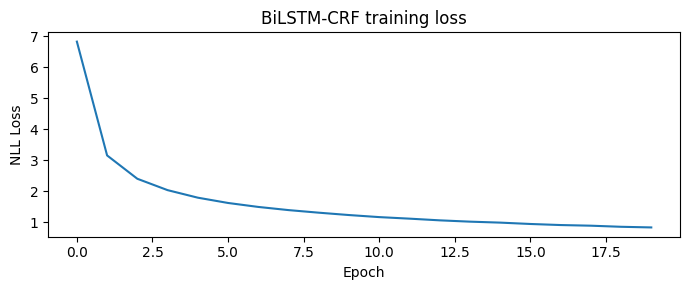

BiLSTM-CRF saved to fitted_models/bilstm_crf.pt
BiLSTM-CRF ready


In [ ]:
BILSTM_PATH = MODEL_DIR / 'bilstm_model' / 'bilstm_crf.pt'

if BILSTM_PATH.exists():
    print(f'BiLSTM-CRF already trained — loading from {BILSTM_PATH}')
    ckpt = torch.load(BILSTM_PATH, map_location=device)
    bilstm_crf = BiLSTMCRF(
        vocab_size=len(vocab), embed_dim=ckpt['embed_dim'],
        hidden_dim=ckpt['hidden_dim'], num_tags=len(tag_map),
        num_layers=ckpt['num_layers'], dropout=ckpt['dropout'],
    ).to(device)
    bilstm_crf.load_state_dict(ckpt['model_state'])
else:
    bilstm_crf = BiLSTMCRF(
        vocab_size=len(vocab), embed_dim=EMBED_DIM,
        hidden_dim=HIDDEN_DIM, num_tags=len(tag_map),
        num_layers=NUM_LAYERS, dropout=DROPOUT,
    ).to(device)
    optimizer = optim.AdamW(bilstm_crf.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)
    print(f'Parameters: {sum(p.numel() for p in bilstm_crf.parameters()):,}')

    train_losses = []
    epoch_bar = tqdm(range(1, EPOCHS + 1), desc='BiLSTM-CRF')
    for epoch in epoch_bar:
        bilstm_crf.train()
        total = 0.0
        for x, y, mask in train_dl:
            x, y, mask = x.to(device), y.to(device), mask.to(device)
            optimizer.zero_grad()
            loss = bilstm_crf(x, y, mask)
            loss.backward()
            nn.utils.clip_grad_norm_(bilstm_crf.parameters(), 5.0)
            optimizer.step()
            total += loss.item()
        avg = total / len(train_dl)
        train_losses.append(avg)
        scheduler.step(avg)
        epoch_bar.set_postfix(loss=f'{avg:.4f}')

    plt.figure(figsize=(7, 3))
    plt.plot(train_losses)
    plt.xlabel('Epoch'); plt.ylabel('NLL Loss')
    plt.title('BiLSTM-CRF training loss')
    plt.tight_layout()
    plt.savefig(MODEL_DIR / 'bilstm_training_loss.png', dpi=120)
    plt.show()

    torch.save({
        'model_state': bilstm_crf.state_dict(),
        'vocab': vocab, 'tag_map': tag_map, 'id2tag': id2tag,
        'embed_dim': EMBED_DIM, 'hidden_dim': HIDDEN_DIM,
        'num_layers': NUM_LAYERS, 'dropout': DROPOUT,
    }, BILSTM_PATH)
    print(f'BiLSTM-CRF saved to {BILSTM_PATH}')

print('BiLSTM-CRF ready')


## 6. Model 4: BERT fine-tuned for NER

**BERT** is a deep bidirectional transformer pre-trained on BooksCorpus + English Wikipedia (3.3B tokens). We fine-tune `bert-base-cased` (12 layers, 768 hidden, 110M parameters) by adding a linear token-classification head on top of the final hidden states.

### Why BERT outperforms the other models on unseen entities

The CRF and Structured Perceptron rely on surface features (word identity, affixes) that only fire if the word was seen in training. The BiLSTM without pre-trained embeddings has the same limitation. BERT's sub-word tokenisation and contextual representations provide meaningful vectors even for words never seen during NER fine-tuning, because the pre-training corpus was orders of magnitude larger.

### Sub-word token alignment

BERT's WordPiece tokeniser splits words into sub-word pieces (e.g. *Washington* → `[Wash, ##ington]`). Since our labels are word-level, only the **first sub-word token** of each word receives the word's label; all continuation pieces receive `-100`, which is ignored by the cross-entropy loss. At inference, predictions are taken from first-piece tokens only.

### Training configuration

| Setting | Value |
|---------|-------|
| Base model | `bert-base-cased` |
| Optimiser | AdamW |
| Learning rate | 2×10⁻⁵ |
| Weight decay | 0.01 |
| Warmup steps | 200 |
| Batch size | 16 |
| Epochs | 6 |
| Max sequence length | 128 |
| Checkpoint selection | Best entity-level F1 (seqeval) via `load_best_model_at_end=True` |
| Mixed precision | fp16 if GPU available |

In [11]:
!pip install 'accelerate>=1.1.0' seqeval -q

In [ ]:
BERT_MODEL  = 'bert-base-cased'
BERT_EPOCHS = 6
BERT_LR     = 2e-5
BERT_BATCH  = 16
BERT_PATH   = MODEL_DIR / 'bert_ner_model'

tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL)
print('Tokenizer loaded')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/436k [00:00<?, ?B/s]

Tokenizer loaded


### Tokenisation and label alignment

The `tokenize_and_align` function handles the word→subword mapping:
- Words are tokenised with `is_split_into_words=True`
- `word_ids()` maps each sub-word position back to its original word index
- First sub-word of each word -> gold label index
- Continuation sub-words and padding -> `-100` (ignored in loss)

In [13]:
def tokenize_and_align(sentences, labels, tokenizer, tag_map, max_length=128):
    tokenized = tokenizer(
        sentences, is_split_into_words=True,
        truncation=True, padding='max_length',
        max_length=max_length, return_tensors='pt',
    )
    aligned_labels = []
    for i, label_seq in enumerate(labels):
        word_ids  = tokenized.word_ids(batch_index=i)
        label_ids, prev_wid = [], None
        for word_id in word_ids:
            if word_id is None:
                label_ids.append(-100)
            elif word_id != prev_wid:
                label_ids.append(tag_map[label_seq[word_id]])
            else:
                label_ids.append(-100)
            prev_wid = word_id
        aligned_labels.append(label_ids)
    tokenized['labels'] = torch.tensor(aligned_labels)
    return tokenized

class NERBertDataset(Dataset):
    def __init__(self, encodings):
        self.encodings = encodings
    def __len__(self): return self.encodings['input_ids'].shape[0]
    def __getitem__(self, idx): return {k: v[idx] for k, v in self.encodings.items()}

print('Encoding train…')
train_enc = tokenize_and_align(train_sents, train_labels, tokenizer, tag_map)
print('Encoding test…')
test_enc  = tokenize_and_align(test_sents,  test_labels,  tokenizer, tag_map)
bert_train_ds = NERBertDataset(train_enc)
bert_test_ds  = NERBertDataset(test_enc)
print(f'Train: {len(bert_train_ds)}  Test: {len(bert_test_ds)}')


Encoding train…
Encoding test…
Train: 38366  Test: 38367


### Fine-tuning

The Hugging Face `Trainer` handles the training loop, gradient accumulation, learning-rate scheduling, per-epoch evaluation and best-checkpoint saving. `compute_metrics` uses **seqeval** entity-level F1 (stricter than token-level F1: an entity is only correct if every token in the span is tagged correctly).

In [14]:
if BERT_PATH.exists():
    print(f'BERT already fine-tuned — loading from {BERT_PATH}')
    bert_model = AutoModelForTokenClassification.from_pretrained(BERT_PATH)
else:
    bert_model = AutoModelForTokenClassification.from_pretrained(
        BERT_MODEL, num_labels=len(tag_map), id2label=id2tag, label2id=tag_map,
    )
    print(f'Parameters: {sum(p.numel() for p in bert_model.parameters()):,}')

    def compute_metrics(p):
        from seqeval.metrics import f1_score as seq_f1
        predictions, labels = p
        predictions = np.argmax(predictions, axis=2)
        true_labels = [[id2tag[l] for l in label if l != -100] for label in labels]
        true_preds  = [
            [id2tag[pred] for pred, l in zip(prediction, label) if l != -100]
            for prediction, label in zip(predictions, labels)
        ]
        return {'f1': seq_f1(true_labels, true_preds)}

    import warnings
    warnings.filterwarnings('ignore', message='.*warmup_ratio.*')

    training_args = TrainingArguments(
        output_dir=str(MODEL_DIR / 'bert_checkpoints'),
        num_train_epochs=BERT_EPOCHS,
        per_device_train_batch_size=BERT_BATCH,
        per_device_eval_batch_size=32,
        learning_rate=BERT_LR,
        weight_decay=0.01,
        warmup_steps=200,
        eval_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model='f1',
        greater_is_better=True,
        logging_strategy='steps',
        logging_steps=100,
        fp16=torch.cuda.is_available(),
        report_to='none',
    )
    data_collator = DataCollatorForTokenClassification(tokenizer)
    trainer = Trainer(
        model=bert_model,
        args=training_args,
        train_dataset=bert_train_ds,
        eval_dataset=bert_test_ds,
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
    trainer.train()

    bert_model.save_pretrained(BERT_PATH)
    tokenizer.save_pretrained(BERT_PATH)
    print(f'BERT saved to {BERT_PATH}')

print('BERT ready')


model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForTokenClassification LOAD REPORT from: bert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly i

Parameters: 107,732,753


Epoch,Training Loss,Validation Loss,F1
1,0.095644,0.202874,0.601112
2,0.078691,0.215154,0.611491
3,0.061936,0.201940,0.640292
4,0.046122,0.231217,0.643487


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

BERT saved to fitted_models/bert_ner
BERT ready
